# Model-based reinforcement learning tutorial

Prepared by Mihály Bányai, 2026. mihaly.s.banyai@gmail.com, https://visionlab-ceu.org/people/mihaly-banyai/ 

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import random
from Levenshtein import distance
from ipynb.fs.defs.AIT26_Tutorial4_RL import transition_probs_from_map, plot_gridworld, evaluate_Q

# The value iteration algorithm

23


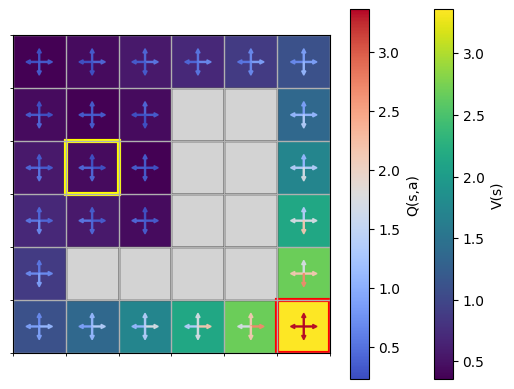

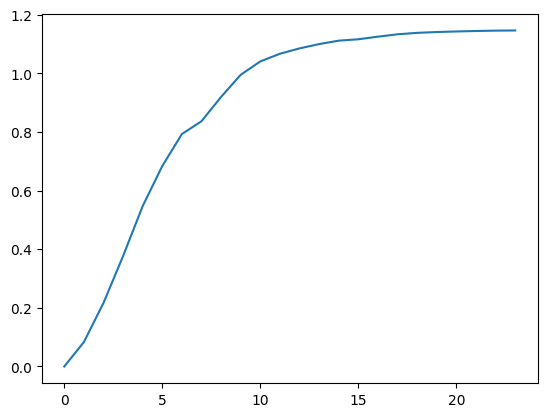

In [9]:
def value_iteration(T, R, gamma, delta_threshold):
    n_states = R.shape[0]
    n_actions = T.shape[2]
    V = np.zeros((n_states))
    Q = np.zeros((n_states, n_actions))
    value_sums = [0]
    delta = np.inf
    iter = 0
    while delta > delta_threshold and iter < 1000:
        delta = 0
        for s in range(n_states):
            deltas_per_action = np.zeros((n_actions))
            for a in range(n_actions):
                Q[s, a] = 0
                for s_prime in range(n_states):
                    Q[s, a] += T[s, s_prime, a] * (R[s] + gamma * V[s_prime])
                deltas_per_action[a] = Q[s, a] - V[s]
            delta = np.maximum(delta, deltas_per_action.max())
            V[s] = Q[s, :].max()
        iter += 1
        value_sums.append(V.sum() / n_states)
    print(iter)
    return V, Q, value_sums

state_map = [
    [0, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 1, 0],
    [0, 0, 0, 1, 1, 0],
    [0, 0, 0, 1, 1, 0],
    [0, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 3]
]

init_state = 13
T_map, R_map = transition_probs_from_map(state_map, start_state=init_state)

V, Q, value_sums = value_iteration(T=T_map, R=R_map, gamma=0.8, delta_threshold=0.01)
plot_gridworld(state_map, init_state, q_function=Q)
plt.plot(value_sums)

## Independent work - how does value iteration scale?
1. Implement an operation counter in the algorithm
2. generate a series of larger and larger environments
3. run value iteration on all of them and plot the computational cost as a function of the number of states

# The Dyna algorithm

## Proritised sweeping

## Independent work - balance of planning vs. acting

R: 171.0


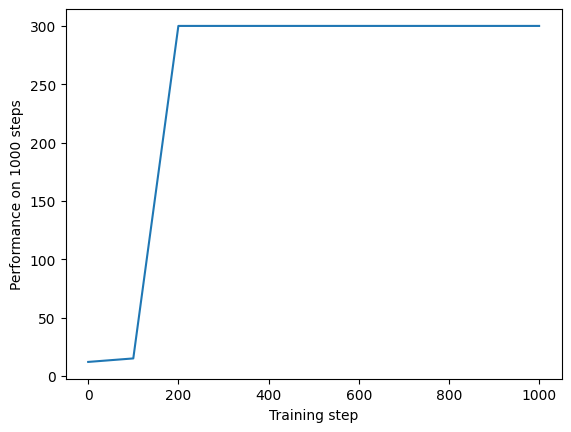

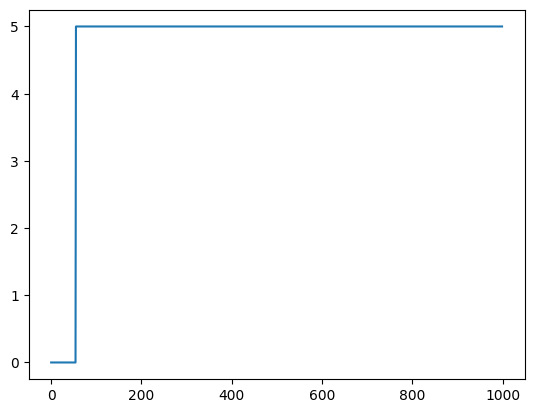

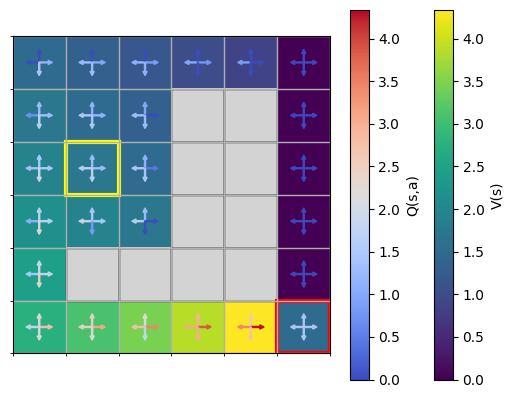

In [102]:
def TD_error(act_state, next_state, action, Q, R, gamma):
    return R[next_state] + gamma * Q[next_state, :].max() - Q[act_state, action]

def insert_into_priority(priority_queue, priority, act_state, next_state, action):
    if priority < 1e-3:
        return
    #print(len(priority_queue) + 1)
    for pi, p in enumerate(priority_queue):
        oldp, s1, s2, a = p
        if s1==act_state and s2==next_state and a==action:
            if oldp > priority:
                return
            else:
                del priority_queue[pi]
    for i, (old_prior, *_) in enumerate(priority_queue):
        if priority > old_prior:  # strictly greater → comes earlier
            priority_queue.insert(i, (priority, act_state, next_state, action))
            return
    priority_queue.append((priority, act_state, next_state, action))

def environment_dynamics(T, R, act_state, action):
    states = list(range(R.shape[0]))
    next_state = np.random.choice(states, size=1, p=T[act_state, :, action].flatten()).item()
    reward = R[next_state]
    return next_state, reward



def dyna(T, R, gamma, max_step, alpha, epsilon, k, init_state, eval_interval=None, eval_step=1000):

    n_states = R.shape[0]
    n_actions = T.shape[2]
    states = list(range(n_states))
    actions = list(range(n_actions))

    Q = np.zeros((n_states, n_actions))
    action_counter = np.zeros((n_states, n_actions))
    T_learned = np.zeros((n_states, n_states, n_actions))
    R_learned = np.zeros(n_states)
    priority_queue = []

    actual_replays_per_step = np.zeros(max_step)
    eval_perfs = [evaluate_Q(T, R, init_state, Q, eval_step) if eval_interval is not None else 0]
    collected_reward = 0

    act_state = init_state
    for i in range(max_step):

        # the epsilon-greedy action selection rule
        if random.uniform(0, 1) < epsilon:
            actions_never_taken = np.argwhere(action_counter[act_state, :] == 0).flatten().tolist()
            if len(actions_never_taken) > 0:
                action = random.choice(actions_never_taken)
            else:
                not_best_actions = np.argwhere(Q[act_state, :] < np.amax(Q[act_state, :])).flatten().tolist()
                if len(not_best_actions) > 0:
                    action = random.choice(not_best_actions)
                else:
                    action = random.choice(actions)
        else:
            best_actions = np.argwhere(Q[act_state, :] == np.amax(Q[act_state, :])).flatten().tolist()
            action = random.choice(best_actions)
        action_counter[act_state, action] += 1

        # the next state is chosen according to the state-action transition probability tensor
        # this is the only place where we use the ground-truth T and R, when we produce the environment's response
        next_state, reward = environment_dynamics(T, R, act_state, action)
        collected_reward += reward

        # model learning, assuming a deterministic environment
        R_learned[next_state] = reward
        T_learned[act_state, next_state, action] = 1

        priority = np.abs(TD_error(act_state, next_state, action, Q, R_learned, gamma))
        insert_into_priority(priority_queue, priority, act_state, next_state, action)

        #if len(priority_queue) > 0: print(priority_queue)

        # replaying k prioritised samples from the model
        for j in range(k):
            # if there are no non-zero priority actions, stop
            if len(priority_queue) == 0:
                break
            actual_replays_per_step[i] += 1
            # choose the highest-priority state-action pair and remove it from the queue
            _, rep_s0, rep_s1, rep_a = priority_queue.pop(0)
            # do a Q-update using the replayed action
            Q[rep_s0, rep_a] += alpha * TD_error(rep_s0, rep_s1, rep_a, Q, R_learned, gamma)
            # check which other actions from which states can lead to rep_s0
            for s in range(n_states):
                if not s == rep_s0:
                    for a in range(n_actions):
                        if T_learned[s, rep_s0, a] > 0:
                            predecessor_priority = np.abs(TD_error(s, rep_s0, a, Q, R_learned, gamma))
                            insert_into_priority(priority_queue, predecessor_priority, s, rep_s0, a)

        #if len(priority_queue) > 0: print('e', priority_queue)

        # performance logging
        if eval_interval is not None and i % eval_interval == 0:
            eval_perfs.append(evaluate_Q(T, R, init_state, Q, eval_step))
        # iterating the state signal for the next step
        act_state = next_state

    if eval_interval is not None:
        plt.plot(np.array(range(len(eval_perfs))) * eval_interval , eval_perfs)
        plt.xlabel("Training step")
        plt.ylabel("Performance on %d steps" % eval_step)

    print("R:", collected_reward)

    return Q, actual_replays_per_step

random.seed(3)    
Q, replays = dyna(T_map, R_map, gamma=0.9, max_step=1000, alpha=0.2, epsilon=0.3, k=5, init_state=init_state, eval_interval=100, eval_step=1000)
plt.figure()
plt.plot(replays)
plot_gridworld(state_map, init_state, q_function=Q)


In [79]:
random.uniform(0, 1)

0.7977799963917469

# Finding replay in neural data

In [9]:
pos = np.genfromtxt("datasets/HC11/position_mm.txt")
spikes = np.genfromtxt("datasets/HC11/spikes_ms.txt")

cellindex = np.array([0,  40,  47,  45,  44,  41,  52,  85,  30, 109,  87,  73,   7,
        61,  64,  90,  10, 106,  25, 111,  96, 114,  51,  42,  98,   1,
        33, 104, 116,   8,  23,  79,   5,  36,  20,  53,  99,  83,  16,
        24,  78,  43,  22,   3,  12,  29,  84,   9,  19,  18,  57, 100,
       118,  65,  38,  67, 102,  35, 112,  94,   6,  66,  69, 105, 101,
        74, 113, 117,  80,  60,  21,  15,  58, 110,  28,  34,  77,  81,
       115,  55,  91,  86,  76,  27,  97,  89, 119,  75,  26,  17,  95,
        93,  31,  46,  54,  14,  88,  62,   2,  11,  56,  68,  48, 108,
        63,  13,  49, 103,  72,  59,  70,  37,  39,  50,  82,  71, 120,
        32,  92,   4, 107])

tmin = 18310
tmax = 18325

ii_spikes = np.flatnonzero((spikes[:,0] > tmin) & (spikes[:,0] < tmax))
sp = spikes[ii_spikes,:]

ii_pos = np.flatnonzero((pos[:,0] > tmin) & (pos[:,0] < tmax))
tx = pos[ii_pos,:]

/var/folders/jw/d5_trdxs6d10y2g48wcnb0880000gn/T/ipykernel_70069/1614044372.py:24: RuntimeWarning: invalid value encountered in divide
  act_mean_spike_time /= act_spike_count


Text(0.5, 0, 'time (s)')

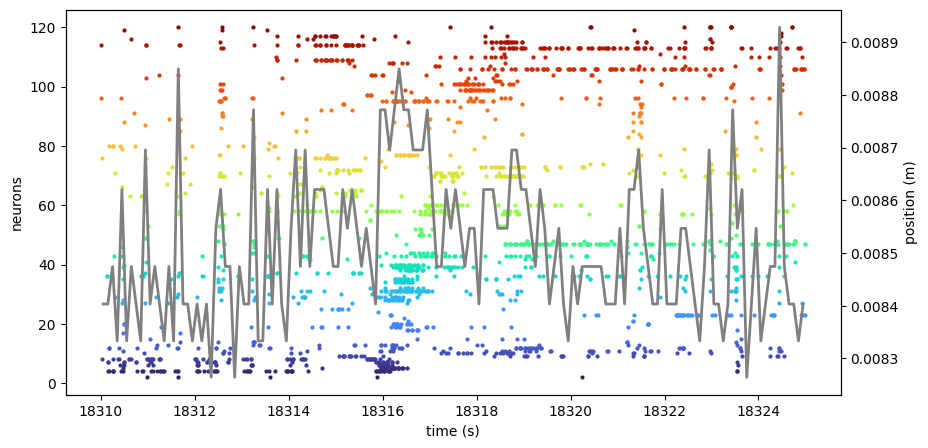

In [10]:

n_cell = len(cellindex)
n_spike = sp.shape[0]

window_width_s = 0.1
window_step_s = 0.1
replay_scores = []
window_midpoints = []

act_window_start = tmin
act_window_end = act_window_start + window_width_s

while act_window_end <= tmax:
    act_spike_count = np.zeros((n_cell))
    act_mean_spike_time = np.zeros((n_cell))

    for spike_idx in range(n_spike):
        spike_time = sp[spike_idx, 0]
        spike_cell = int(sp[spike_idx, 1])
        if spike_time >= act_window_start and spike_time < act_window_end:
            act_spike_count[spike_cell] += 1
            act_mean_spike_time[spike_cell] += spike_time
        #elif spike_time >= act_window_end:
        #    break
    act_mean_spike_time /= act_spike_count
    #print(act_mean_spike_time)
    cells_spiked = np.flatnonzero(act_spike_count)
    ordering_indices = np.argsort(act_mean_spike_time[cells_spiked])
    codeword = cells_spiked[ordering_indices]
    replay_score = 1. / distance(codeword, cellindex)
    replay_scores.append(replay_score)
    window_midpoints.append(act_window_start + (act_window_end - act_window_start) / 2)
    act_window_start += window_step_s
    act_window_end += window_step_s
    
cmap = mpl.colormaps['turbo']
fig, ax = plt.subplots(figsize=(10, 5))
ax2 = ax.twinx()
ax2.plot(window_midpoints, replay_scores, c='grey', zorder=1, linewidth=2)

for i_cell in np.arange(121):
    idx = np.flatnonzero(sp[:,1] == i_cell)
    if (len(idx) > 0):
        jj = np.flatnonzero(cellindex == i_cell)
        ax.scatter(sp[idx,0], np.ones(len(idx)) * jj, s=4, c=cmap(jj/121), zorder=2)
        
        # ax.scatter(sp[idx,0], np.ones(len(idx)) * i_cell, s=4, c='k')
ax2.set_ylabel('position (m)')
ax.set_ylabel('neurons')
ax.set_xlabel('time (s)')

## Independent work - the time scale of replay

- assess the time scale of mental replay in relation to the time scale of actual movement
- is there a single time scale or multiple?

## Homework problems

### 1. Explore the replay sequences found by the Levenshtein score
- compare the ones before and after the actual movement of the animal

### 2. Implement environments with sudden change
- compare Q-learning to Dyna-PS

### 3. Implement tree-search-based planning using a model
- estimate the value of a particular action in a particular state by rolling out possible state sequences to a finite depth
- try out cuts in terms of probability or value

### 4. Use tree search to plan in the belief MDP of a 2-armed bandit problem
- assess how the belief states would transition into each other upon any observation
- estimate the value of the two actions using a finite-depth tree search